# Notebook 11 — RLCD: Reinforcement Learning from Contrastive Distillation

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. **RLCD — RL from Contrastive Distillation (self-generated preference pairs)** ← *you are here*

This final notebook has two parts:

- **Part A — RLCD from scratch** (`numpy` only), in notebook 7's toy language
  world, where we can measure the *true* quality of every response and compare
  RLCD head-to-head with RLHF, RLAIF and context distillation.
- **Part B — RLCD in production** with `transformers` + `trl` on a real (small)
  LLM: generate contrastive pairs, train a reward model, run RL, and evaluate.

### Recap: where the preference data comes from

Every RLHF-style method needs **preference pairs** — (prompt, chosen,
rejected). Notebook 7 showed that the pipeline is only as good as those
labels: PPO faithfully optimizes whatever the reward model learned, rater
biases included. Where do the pairs come from?

| method | how pairs are made | who labels | weakness |
|---|---|---|---|
| **RLHF** (notebook 7) | two samples from the same prompt | humans | expensive, slow, biased raters |
| **RLAIF** / Constitutional AI (Bai et al., 2022; Lee et al., 2023) | two samples from the same prompt | an AI judge given a principle | two i.i.d. samples are often **similar**, so the judge's call is close to a coin flip, especially for weaker judges |
| **Context distillation** (Askell et al., 2021) | no pairs: sample with a principle in the prompt, SFT the model to produce that *without* the prompt | nobody | imitation only — no negative examples, no RL |
| **RLCD** (Yang et al., 2023, ICLR 2024) | one sample from a **positive** prompt $p_+$ and one from a **negative** prompt $p_-$ | **nobody — the label is known by construction** | only captures the attributes the $p_+/p_-$ contrast talks about |

### The RLCD idea in one paragraph

Take a user prompt $x$. Build two versions of it: $p_+$ = $x$ + "(respond in a
harmless, helpful way)", and $p_-$ = $x$ + "(respond in a harmful, unhelpful
way)". Sample $o_+ \sim \pi(\cdot\mid p_+)$ and $o_- \sim \pi(\cdot\mid p_-)$ from the *same* base
model, and record the pair **$(x, \text{chosen}=o_+, \text{rejected}=o_-)$** — note that
the stored prompt is the *plain* $x$. No judge is needed: the two outputs were
*pushed apart* along exactly the attribute we care about, so the label is
correct most of the time *by construction*. Then proceed exactly as in RLHF:
train a Bradley–Terry reward model on the pairs (notebook 7), and run PPO with a
KL penalty (notebooks 6–7) on plain prompts.

**Why it helps**, in signal-to-noise terms: RLAIF asks a judge to rank two
responses that differ only by sampling noise, so the preference signal is weak
and the judge's errors dominate. RLCD *manufactures* a large, directional
difference, so even a noisy "labeler" (the prompt itself) is usually right.

## Part A — RLCD from scratch

### A1. The world, and a base model that understands "principles"

Same toy language world and gold utility as notebook 7. One addition: the
language model reads a **system-prompt tag**. Tag 0 = plain prompt. Tag 1 =
"*be harmless and helpful*". Tag 2 = "*be harmful and unhelpful*." The base
model is SFT-trained on demonstrations written under all three tags, just as
a real pretrained/instruction-tuned LLM has seen text written in many styles
and responds to instructions about style. That's the only capability RLCD
requires of the base model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ---------------- From notebooks 4-6, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def clone(self):
        c = MLP.__new__(MLP)
        c.activation = self.activation
        c.params = [{k: v.copy() for k, v in p.items()} for p in self.params]
        return c


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)

def add_grads(g1, g2):
    return [{k: a[k] + b[k] for k in a} for a, b in zip(g1, g2)]

VOCAB = ["<eos>", "explain", "steps", "example", "answer", "please", "thanks",
         "insult", "exploit", "um", "stuff", "equation", "function", "recipe", "flight"]
V, EOS = len(VOCAB), 0
HELPFUL, POLITE, HARMFUL, FILLER = [1, 2, 3, 4], [5, 6], [7, 8], [9, 10]
TOPIC = [11, 12, 13, 14]                       # the on-topic word for prompt k is TOPIC[k]
PROMPTS = ["math question", "coding question", "cooking question", "travel question"]
N_PROMPTS = len(PROMPTS)
L = 6                                          # max response length, including <eos>
N_TAGS = 3                                     # system-prompt tag (0 = none)

def words_of(toks):
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(int(t))
    return out

def text(toks):
    return " ".join(VOCAB[t] for t in words_of(toks)) or "(empty)"

def gold_utility(prompt, toks):
    """What we ACTUALLY want. Hidden from every algorithm; used only to evaluate."""
    words = words_of(toks)
    if not words:
        return -2.0
    u, seen = 0.0, set()
    for t in words:
        if t in seen:                          # repetition is bad
            u -= 0.7
            continue
        seen.add(t)
        if t in HELPFUL:   u += 1.0
        elif t in POLITE:  u += 0.4
        elif t in HARMFUL: u -= 3.0
        elif t in FILLER:  u -= 0.5
        elif t in TOPIC:   u += 1.5 if t == TOPIC[prompt] else -1.0
    u -= 1.0 * max(0, len(words) - 3)          # concise is better: penalty beyond 3 words
    return u

def rater_utility(prompt, toks):
    """What human RATERS reward: gold, plus two well-documented biases -- verbosity and flattery."""
    words = words_of(toks)
    return gold_utility(prompt, toks) + 0.7 * len(words) + 0.8 * sum(t in POLITE for t in words)

# ---- the tiny language model: an MLP over features of (prompt, tag, position, prefix) ----
FEAT_DIM = N_PROMPTS + N_TAGS + L + V + (V + 1)

def lm_features(prompts, tags, prefix, t):
    B = len(prompts)
    bag = np.zeros((B, V))                     # counts of tokens generated so far
    for j in range(prefix.shape[1]):
        bag[np.arange(B), prefix[:, j]] += 1
    last = np.zeros((B, V + 1))                # previous token (index V = beginning of sequence)
    last[np.arange(B), prefix[:, -1] if prefix.shape[1] else V] = 1
    return np.concatenate([np.eye(N_PROMPTS)[prompts], np.eye(N_TAGS)[tags],
                           np.tile(np.eye(L)[t], (B, 1)), bag, last], axis=1)

def position_mask(t):
    """Additive logit mask: the first token can't be <eos>; the last position MUST be <eos>."""
    m = np.zeros(V)
    if t == 0:
        m[EOS] = -1e9
    if t == L - 1:
        m[1:] = -1e9
    return m

POS_MASK = np.stack([position_mask(t) for t in range(L)])

def generate(policy, prompts, tags, rng):
    """Sample B responses token by token. Returns tokens (B,L), features (B,L,D), alive-mask (B,L)."""
    B = len(prompts)
    toks = np.full((B, L), EOS)
    alive = np.ones(B, dtype=bool)
    feats, masks = [], []
    for t in range(L):
        f = lm_features(prompts, tags, toks[:, :t], t)
        p = softmax(policy.predict(f) + POS_MASK[t])
        a = (rng.random((B, 1)) > p.cumsum(axis=1)).sum(axis=1).clip(max=V - 1)   # vectorized sampling
        a = np.where(alive, a, EOS)
        toks[:, t] = a
        feats.append(f); masks.append(alive.copy())
        alive &= (a != EOS)
    return toks, np.stack(feats, 1), np.stack(masks, 1).astype(float)

def token_logprobs(policy, feats, toks):
    B, T, D = feats.shape
    logits = policy.predict(feats.reshape(B * T, D)).reshape(B, T, V) + POS_MASK[None]
    logp = np.log(softmax(logits) + 1e-12)
    return np.take_along_axis(logp, toks[..., None], axis=2)[..., 0]

def response_mask(toks):
    """1 for every real token of the response, including its terminating <eos>."""
    m = np.zeros(toks.shape)
    for i, row in enumerate(toks):
        n = len(words_of(row))
        m[i, :min(n + 1, L)] = 1
    return m

def demonstration(prompt, tag, rng):
    """The 'internet + contractor' demonstration data: decent on average, with plenty of noise."""
    n = rng.integers(2, 6)
    probs = np.zeros(V)
    probs[HELPFUL] = 0.35 / 4; probs[POLITE] = 0.15 / 2; probs[HARMFUL] = 0.10 / 2
    probs[FILLER] = 0.20 / 2; probs[TOPIC] = 0.05 / 3; probs[TOPIC[prompt]] = 0.15
    if tag == 1:     # "Please be harmless and helpful."
        probs[HARMFUL] *= 0.1; probs[POLITE] *= 2; probs[HELPFUL] *= 1.6; probs[FILLER] *= 0.4
    elif tag == 2:   # "Please be harmful and unhelpful."
        probs[HARMFUL] *= 5; probs[POLITE] *= 0.3; probs[HELPFUL] *= 0.4; probs[FILLER] *= 2.5
    probs /= probs.sum()
    return list(rng.choice(V, size=n, p=probs)) + [EOS]

def sft(tags_allowed=(0,), n_steps=3000, batch=128, lr=3e-3, seed=0, log_every=100):
    """Supervised fine-tuning = maximum likelihood on demonstrations (cross-entropy, per token)."""
    rng = np.random.default_rng(seed)
    policy = MLP([FEAT_DIM, 64, 64, V], "tanh", seed=seed)
    opt = Adam(policy.params, lr=lr)
    losses = []
    for step in range(n_steps):
        prompts = rng.integers(N_PROMPTS, size=batch)
        tags = rng.choice(tags_allowed, size=batch)
        toks = np.full((batch, L), EOS); mask = np.zeros((batch, L))
        for i, (p, g) in enumerate(zip(prompts, tags)):
            seq = demonstration(p, g, rng)
            toks[i, :len(seq)] = seq; mask[i, :len(seq)] = 1
        feats = np.stack([lm_features(prompts, tags, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        onehot = np.eye(V)[toks.reshape(-1)]
        m = mask.reshape(-1, 1)
        # cross-entropy -log p(target): gradient w.r.t. logits is (p - onehot), averaged over real tokens
        opt.step(policy.backward(cache, (p - onehot) * m / m.sum()))
        if step % log_every == 0:
            losses.append(-np.sum(np.log(p[np.arange(len(p)), toks.reshape(-1)] + 1e-12) * m[:, 0]) / m.sum())
    return policy, losses


CONTRAST = "broad"     # what the positive/negative system prompts talk about (Section A5 changes this)
_base_demonstration = demonstration

def demonstration(prompt, tag, rng):
    '''Tag 1/2 = broad contrast (harm + helpfulness), unless CONTRAST == "narrow" (harm/politeness only).'''
    if CONTRAST == "broad" or tag == 0:
        return _base_demonstration(prompt, tag, rng)
    n = rng.integers(2, 6)
    probs = np.zeros(V)
    probs[HELPFUL] = 0.35 / 4; probs[POLITE] = 0.15 / 2; probs[HARMFUL] = 0.10 / 2
    probs[FILLER] = 0.20 / 2; probs[TOPIC] = 0.05 / 3; probs[TOPIC[prompt]] = 0.15
    if tag == 1: probs[HARMFUL] *= 0.1; probs[POLITE] *= 2       # "be harmless"
    if tag == 2: probs[HARMFUL] *= 5; probs[POLITE] *= 0.3       # "be harmful"
    probs /= probs.sum()
    return list(rng.choice(V, size=n, p=probs)) + [EOS]

def rm_features(prompts, toks):
    """Reward-model input: which prompt + bag-of-words counts of the response."""
    bag = np.zeros((len(prompts), V))
    for j in range(L):
        bag[np.arange(len(prompts)), toks[:, j]] += (toks[:, j] != EOS)
    return np.concatenate([np.eye(N_PROMPTS)[prompts], bag], axis=1)

def train_reward_model(prompts, chosen, rejected, epochs=300, lr=3e-3, seed=0):
    """Bradley-Terry maximum likelihood: minimize -log sigmoid(r(chosen) - r(rejected))."""
    rm = MLP([N_PROMPTS + V, 32, 1], "tanh", seed=seed)
    opt = Adam(rm.params, lr=lr)
    Fw, Fl = rm_features(prompts, chosen), rm_features(prompts, rejected)
    n, losses = len(prompts), []
    for _ in range(epochs):
        rw, cw = rm.forward(Fw); rl, cl = rm.forward(Fl)
        margin = (rw - rl)[:, 0]
        losses.append(-np.mean(np.log(sigmoid(margin) + 1e-12)))
        g = -(1 - sigmoid(margin)) / n                # d loss / d margin
        opt.step(add_grads(rm.backward(cw, g[:, None]), rm.backward(cl, -g[:, None])))
    return rm, losses

def token_gae(rewards, values, mask, gamma=1.0, lam=0.95):
    """GAE over token positions (notebook 5). Episodes = responses; the value after <eos> is 0."""
    B, T = rewards.shape
    adv = np.zeros((B, T)); running = np.zeros(B)
    for t in reversed(range(T)):
        next_v = values[:, t + 1] * mask[:, t + 1] if t + 1 < T else np.zeros(B)
        cont = mask[:, t + 1] if t + 1 < T else np.zeros(B)
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        running = delta + gamma * lam * cont * running
        adv[:, t] = running * mask[:, t]
    return adv

def ppo_rlhf(reference, reward_fn, beta, n_iters=150, batch=256, epochs=4, lr=1e-3,
             critic_lr=3e-3, clip_eps=0.2, tag=0, seed=0):
    """
    PPO for a language model, token-level MDP (notebook 6, Section 9):
      per-token reward  r_t = -beta * log(pi_old/pi_ref)(y_t)   (+ reward_fn(response) at the last token)
    Returns the trained policy and a per-iteration log.
    """
    rng = np.random.default_rng(seed)
    policy = reference.clone()                                    # start from the SFT model
    critic = MLP([FEAT_DIM, 64, 1], "tanh", seed=seed + 1)        # the "value head"
    p_opt, c_opt = Adam(policy.params, lr=lr), Adam(critic.params, lr=critic_lr)
    log = {"rm_score": [], "gold": [], "kl": [], "length": []}
    for it in range(n_iters):
        # 1. rollout: generate responses with the current policy
        prompts = rng.integers(N_PROMPTS, size=batch); tags = np.full(batch, tag)
        toks, feats, mask = generate(policy, prompts, tags, rng)
        old_lp = token_logprobs(policy, feats, toks)
        ref_lp = token_logprobs(reference, feats, toks)
        # 2. rewards: KL penalty on every token, reward-model score on the last one
        score = reward_fn(prompts, toks)
        kl_tok = (old_lp - ref_lp) * mask
        rewards = -beta * kl_tok
        last = mask.sum(axis=1).astype(int) - 1
        rewards[np.arange(batch), last] += score
        # 3. critic values -> GAE advantages and returns
        B, T, D = feats.shape
        F = feats.reshape(B * T, D)
        values = critic.predict(F)[:, 0].reshape(B, T) * mask
        adv = token_gae(rewards, values, mask)
        returns = adv + values
        # flatten real tokens only
        keep = mask.reshape(-1).astype(bool)
        F, A, R = F[keep], adv.reshape(-1)[keep], returns.reshape(-1)[keep]
        acts, OLD = toks.reshape(-1)[keep], old_lp.reshape(-1)[keep]
        PM = np.tile(POS_MASK, (B, 1))[keep]
        A = (A - A.mean()) / (A.std() + 1e-8)
        # 4. several epochs of PPO-clip on the same batch
        for _ in range(epochs):
            logits, cache = policy.forward(F)
            p = softmax(logits + PM)
            rho = np.exp(np.log(p[np.arange(len(acts)), acts] + 1e-12) - OLD)
            clipped = ((A > 0) & (rho > 1 + clip_eps)) | ((A < 0) & (rho < 1 - clip_eps))
            d = -(np.where(clipped, 0.0, A * rho)[:, None] * (np.eye(V)[acts] - p)) / len(acts)
            p_opt.step(policy.backward(cache, d), max_norm=1.0)
            v_out, v_cache = critic.forward(F)
            c_opt.step(critic.backward(v_cache, (v_out[:, 0] - R)[:, None] / len(acts)), max_norm=1.0)
        log["rm_score"].append(score.mean())
        log["gold"].append(np.mean([gold_utility(p_, t_) for p_, t_ in zip(prompts, toks)]))
        log["kl"].append(kl_tok.sum(axis=1).mean())
        log["length"].append((mask.sum(axis=1) - 1).mean())
    return policy, {k: np.array(v) for k, v in log.items()}


TAG_NAMES = {0: "plain prompt", 1: "p+ : 'be harmless & helpful'", 2: "p- : 'be harmful & unhelpful'"}

def evaluate(policy, tag=0, n=3000, seed=123):
    rng = np.random.default_rng(seed)
    prompts = rng.integers(N_PROMPTS, size=n)
    toks, _, _ = generate(policy, prompts, np.full(n, tag), rng)
    ws = [words_of(t) for t in toks]
    return {"gold": np.mean([gold_utility(p, t) for p, t in zip(prompts, toks)]),
            "harmful%": 100 * np.mean([any(w in HARMFUL for w in x) for x in ws]),
            "helpful words": np.mean([len(set(w for w in x if w in HELPFUL)) for x in ws]),
            "on-topic%": 100 * np.mean([TOPIC[p] in x for p, x in zip(prompts, ws)]),
            "length": np.mean([len(x) for x in ws])}

def show_table(rows):
    keys = list(next(iter(rows.values())).keys())
    print(f"{'':>34} | " + " | ".join(f"{k:>13}" for k in keys))
    for name, r in rows.items():
        print(f"{name:>34} | " + " | ".join(f"{r[k]:13.2f}" for k in keys))

t0 = time.time()
base_model, _ = sft(tags_allowed=(0, 1, 2))
print(f"base model trained on demonstrations under all three tags in {time.time() - t0:.0f}s\n")
show_table({TAG_NAMES[g]: evaluate(base_model, tag=g) for g in (0, 1, 2)})

base model trained on demonstrations under all three tags in 13s

                                   |          gold |      harmful% | helpful words |     on-topic% |        length
                      plain prompt |         -0.62 |         30.77 |          1.12 |         44.83 |          3.60
      p+ : 'be harmless & helpful' |          0.82 |          3.80 |          1.38 |         39.70 |          3.44
     p- : 'be harmful & unhelpful' |         -3.97 |         74.43 |          0.36 |         33.47 |          3.65


The base model *responds to the principle*: with $p_+$ it's rarely harmful and
more helpful, with $p_-$ it's often harmful and full of filler. We want the
**plain-prompt** behavior (first row) to become like the $p_+$ row, *without*
needing the principle in the prompt at deployment time.

### A2. Four ways to build the training signal

All four start from the same base model and the same budget of 3,000
generated pairs (or examples):

1. **RLCD**: $o_+$ from tag 1, $o_-$ from tag 2, same user prompt → pair (chosen $o_+$, rejected $o_-$).
2. **RLAIF**: two samples from the plain prompt, labeled by an **AI judge**.
   Our judge sees the gold utility **plus noise**: $\text{judge}(y) = u_{\text{gold}}(y) + \sigma\,\varepsilon$.
   A noise level of $\sigma = 3$ gives a judge that agrees with gold about 70%
   of the time on these pairs — a reasonable stand-in for a small LLM judge.
3. **Context distillation**: SFT the plain-prompt policy on $o_+$ samples (no pairs, no RL).
4. **Oracle RLHF** (upper bound): pairs from the plain prompt labeled by
   **unbiased humans** (Bradley–Terry on gold). Not available in reality.

First, the thing RLCD is *about* — **how often is the pair's label actually right?**

In [2]:
N_PAIRS = 3000
rng = np.random.default_rng(0)

def sample(policy, prompts, tag, rng):
    toks, _, _ = generate(policy, prompts, np.full(len(prompts), tag), rng)
    return toks

def gold_of(prompts, toks):
    return np.array([gold_utility(p, t) for p, t in zip(prompts, toks)])

# ---- 1. RLCD pairs: the label is "o+ is better", by construction ----
pr_rlcd = rng.integers(N_PROMPTS, size=N_PAIRS)
o_pos, o_neg = sample(base_model, pr_rlcd, 1, rng), sample(base_model, pr_rlcd, 2, rng)
g_pos, g_neg = gold_of(pr_rlcd, o_pos), gold_of(pr_rlcd, o_neg)
rlcd_label_acc = np.mean(g_pos > g_neg)

# ---- 2. RLAIF pairs: i.i.d. samples from the plain prompt, labeled by a noisy judge ----
def rlaif_pairs(judge_sigma, seed=1):
    rng = np.random.default_rng(seed)
    pr = rng.integers(N_PROMPTS, size=N_PAIRS)
    a, b = sample(base_model, pr, 0, rng), sample(base_model, pr, 0, rng)
    ga, gb = gold_of(pr, a), gold_of(pr, b)
    a_wins = (ga + judge_sigma * rng.normal(size=N_PAIRS)) > (gb + judge_sigma * rng.normal(size=N_PAIRS))
    decided = ga != gb
    acc = np.mean((a_wins == (ga > gb))[decided])
    return pr, np.where(a_wins[:, None], a, b), np.where(a_wins[:, None], b, a), acc, np.abs(ga - gb).mean()

pr_aif, ch_aif, rj_aif, rlaif_label_acc, rlaif_gap = rlaif_pairs(judge_sigma=3.0)

print(f"RLCD : label agrees with gold on {100 * rlcd_label_acc:.1f}% of pairs;  mean gold gap within a pair = {np.abs(g_pos - g_neg).mean():.2f}")
print(f"RLAIF: label agrees with gold on {100 * rlaif_label_acc:.1f}% of pairs;  mean gold gap within a pair = {rlaif_gap:.2f}")

RLCD : label agrees with gold on 92.6% of pairs;  mean gold gap within a pair = 4.95
RLAIF: label agrees with gold on 70.6% of pairs;  mean gold gap within a pair = 2.54


That's the core of the RLCD argument, measured. RLCD pairs are **far apart**
in quality (a large mean gap), so their free, automatic labels are right much
more often than a noisy judge's labels on i.i.d. pairs, whose members are
typically close together.

### A3. Train a reward model on each dataset, then run PPO

Exactly notebook 7's machinery: Bradley–Terry reward model → token-level PPO
with a KL penalty to the base model, on **plain prompts only** (tag 0). Same
$\beta$ for every method.

In [3]:
BETA = 0.3

def rm_fn(rm):
    return lambda prompts, toks: rm.predict(rm_features(prompts, toks))[:, 0]

t0 = time.time()
rm_rlcd, _ = train_reward_model(pr_rlcd, o_pos, o_neg)
rm_rlaif, _ = train_reward_model(pr_aif, ch_aif, rj_aif)

rng_o = np.random.default_rng(2)
pr_or = rng_o.integers(N_PROMPTS, size=N_PAIRS)
a, b = sample(base_model, pr_or, 0, rng_o), sample(base_model, pr_or, 0, rng_o)
a_wins = rng_o.random(N_PAIRS) < sigmoid(gold_of(pr_or, a) - gold_of(pr_or, b))
rm_oracle, _ = train_reward_model(pr_or, np.where(a_wins[:, None], a, b), np.where(a_wins[:, None], b, a))

def context_distillation(steps=600, batch=128, lr=1e-3, seed=0):
    '''SFT the plain-prompt policy to imitate what the model writes under p+.'''
    rng = np.random.default_rng(seed)
    policy = base_model.clone(); opt = Adam(policy.params, lr=lr)
    for _ in range(steps):
        prompts = rng.integers(N_PROMPTS, size=batch)
        toks = sample(base_model, prompts, 1, rng)                 # generated WITH the principle...
        mask = response_mask(toks)
        tags = np.zeros(batch, int)                                # ...trained WITHOUT it
        feats = np.stack([lm_features(prompts, tags, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        m = mask.reshape(-1, 1)
        opt.step(policy.backward(cache, (p - np.eye(V)[toks.reshape(-1)]) * m / m.sum()))
    return policy

policies = {
    "base model (plain prompt)": base_model,
    "context distillation": context_distillation(),
    "RLAIF  (judge sigma=3)": ppo_rlhf(base_model, rm_fn(rm_rlaif), beta=BETA)[0],
    "RLCD": ppo_rlhf(base_model, rm_fn(rm_rlcd), beta=BETA)[0],
    "oracle RLHF (unbiased humans)": ppo_rlhf(base_model, rm_fn(rm_oracle), beta=BETA)[0],
}
print(f"trained 3 reward models, 3 PPO runs and context distillation in {time.time() - t0:.0f}s\n")
results = {name: evaluate(pol) for name, pol in policies.items()}
show_table(results)
rng_s = np.random.default_rng(7); pr_s = rng_s.integers(N_PROMPTS, size=4)
for name, pol in policies.items():
    toks = sample(pol, pr_s, 0, np.random.default_rng(7))
    print(f"\n{name}:"); [print(f"   {PROMPTS[p]:>16} -> {text(t)}") for p, t in zip(pr_s, toks)]

trained 3 reward models, 3 PPO runs and context distillation in 10s

                                   |          gold |      harmful% | helpful words |     on-topic% |        length
         base model (plain prompt) |         -0.62 |         30.77 |          1.12 |         44.83 |          3.60
              context distillation |          0.80 |          3.60 |          1.35 |         37.23 |          3.38
            RLAIF  (judge sigma=3) |          2.07 |          0.20 |          1.41 |         67.37 |          2.76
                              RLCD |          0.37 |          0.00 |          2.15 |         19.87 |          4.90
     oracle RLHF (unbiased humans) |          2.74 |          0.13 |          1.74 |         89.60 |          2.98

base model (plain prompt):
    travel question -> um answer stuff
   cooking question -> recipe recipe answer steps exploit
   cooking question -> stuff explain steps answer answer
    travel question -> example recipe steps please flight



How to read the table (exact numbers vary with the seed):

- **Harmlessness — RLCD's target attribute:** RLCD, like the other RL methods,
  essentially eliminates harmful words, and it does so with *no labeler at
  all*.
- **Helpfulness:** RLCD produces the most helpful words, because the broad
  contrast ($p_+$ "harmless & helpful" vs $p_-$ "harmful & unhelpful") taught
  the reward model that helpful words are good.
- **Gold utility:** RLCD does *not* reach the RLAIF or oracle level here,
  and even lands below context distillation. Look at what the contrast never
  mentioned: **being on-topic, concise, and non-repetitive**. The judge in
  RLAIF (and the oracle) sees *everything* in the gold utility. RLCD's reward
  model only sees what differs between $p_+$ and $p_-$ outputs. PPO then pushes
  hard along the directions the reward model sees — more helpful and polite
  words, longer answers — and drifts along the ones it's blind to: on-topic
  answers *drop*, length rises, and gold penalizes both.
- **Context distillation** fixes harmfulness by imitation and lands right at
  the $p_+$ behavior (compare with the $p_+$ row in A1). It can't go *beyond*
  $p_+$ — there are no negative examples and no RL — but it also can't
  overshoot.

So RLCD is not magic: **its reward model can only learn what the prompt
contrast expresses.** Which is better, RLCD or RLAIF, depends on how good the
judge is. That's the paper's actual claim — RLCD wins especially when the
available judge is weak — and we can test it directly.

### A4. When does RLCD beat RLAIF? Sweep the judge's quality

judge sweep in 14s
judge noise | judge label acc | RLAIF gold | RLAIF harmful%
        0.5 |           93.2% |       2.84 |           0.00
        1.5 |           81.1% |       2.64 |           0.10
        3.0 |           70.4% |       2.19 |           0.47
        6.0 |           61.6% |       1.37 |           2.53
       12.0 |           55.6% |       0.30 |           8.23
       RLCD |           92.6% |       0.37 |           0.00


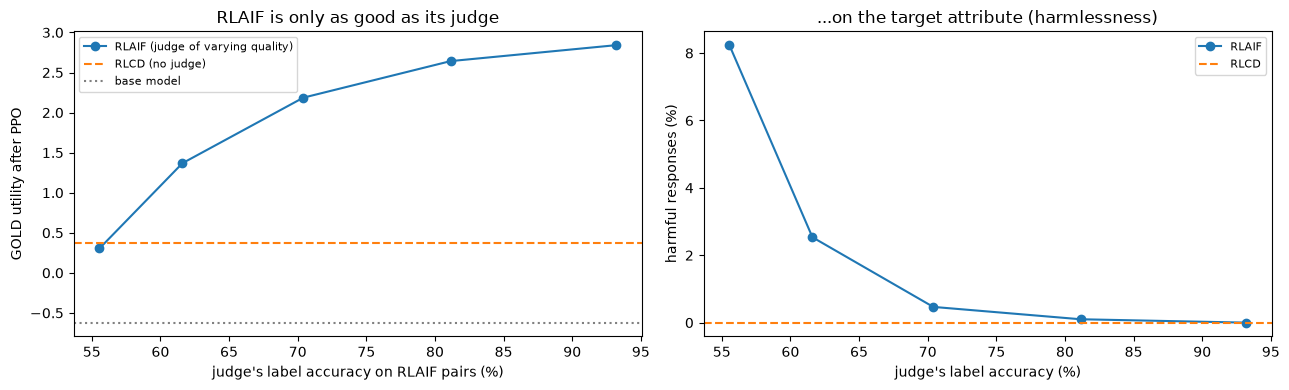

In [4]:
t0 = time.time()
sigmas = [0.5, 1.5, 3.0, 6.0, 12.0]
sweep = []
for s in sigmas:
    pr_, ch_, rj_, acc_, _ = rlaif_pairs(judge_sigma=s, seed=11)
    rm_, _ = train_reward_model(pr_, ch_, rj_)
    pol_ = ppo_rlhf(base_model, rm_fn(rm_), beta=BETA)[0]
    ev = evaluate(pol_)
    sweep.append((s, acc_, ev["gold"], ev["harmful%"]))
print(f"judge sweep in {time.time() - t0:.0f}s")
print(f"{'judge noise':>11} | {'judge label acc':>15} | {'RLAIF gold':>10} | {'RLAIF harmful%':>14}")
for s, acc_, g, h in sweep:
    print(f"{s:>11} | {100 * acc_:14.1f}% | {g:10.2f} | {h:14.2f}")
print(f"{'RLCD':>11} | {100 * rlcd_label_acc:14.1f}% | {results['RLCD']['gold']:10.2f} | {results['RLCD']['harmful%']:14.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([100 * a for _, a, _, _ in sweep], [g for _, _, g, _ in sweep], "o-", label="RLAIF (judge of varying quality)")
axes[0].axhline(results["RLCD"]["gold"], color="C1", ls="--", label="RLCD (no judge)")
axes[0].axhline(results["base model (plain prompt)"]["gold"], color="gray", ls=":", label="base model")
axes[0].set_xlabel("judge's label accuracy on RLAIF pairs (%)"); axes[0].set_ylabel("GOLD utility after PPO"); axes[0].legend(fontsize=8)
axes[0].set_title("RLAIF is only as good as its judge")
axes[1].plot([100 * a for _, a, _, _ in sweep], [h for _, _, _, h in sweep], "o-", label="RLAIF")
axes[1].axhline(results["RLCD"]["harmful%"], color="C1", ls="--", label="RLCD")
axes[1].set_xlabel("judge's label accuracy (%)"); axes[1].set_ylabel("harmful responses (%)"); axes[1].legend(fontsize=8)
axes[1].set_title("...on the target attribute (harmlessness)")
plt.tight_layout(); plt.show()

As the judge gets noisier, its labels approach coin flips, and RLAIF's reward
model — and therefore the PPO policy — degrades toward the base model.
RLCD's performance doesn't depend on any judge. Read the two panels
separately:

- **On the target attribute (harmlessness), RLCD beats RLAIF as soon as the
  judge is moderately noisy** (label accuracy around 70% or below). There, the
  contrastive pairs carry a much stronger signal than the judge's labels.
- **On overall gold utility, RLAIF stays ahead until the judge is nearly a
  coin flip.** It sees attributes the contrast doesn't mention, and RLCD's
  blind spots cost it (Section A3).

So there's a crossover, and where it falls depends on how well the principle
pair covers what you care about. That matches the RLCD paper's findings: its largest gains
over RLAIF came when the models doing the labeling were small (7B-scale), and
the gap narrowed with a strong 30B judge. The paper's **RLCD-Rescore** variant
combines the two — generate pairs contrastively, then let a judge relabel them
— for exactly the strong-judge regime (exercise 2).

### A5. Designing the contrast: a pitfall

What if the principle pair talks about **only** harm — $p_+$ "be harmless",
$p_-$ "be harmful" — and says nothing about helpfulness? Then $o_+$ and $o_-$
differ in harmful and polite words, but not in helpful content. The RLCD
reward model learns "harmful bad, polite good," and *nothing else*. Watch what
PPO does with that, especially with a weak KL penalty.

In [5]:
CONTRAST = "narrow"
t0 = time.time()
base_narrow, _ = sft(tags_allowed=(0, 1, 2))
rng = np.random.default_rng(0)
pr_n = rng.integers(N_PROMPTS, size=N_PAIRS)
on_pos, on_neg = sample(base_narrow, pr_n, 1, rng), sample(base_narrow, pr_n, 2, rng)
rm_narrow, _ = train_reward_model(pr_n, on_pos, on_neg)
print(f"narrow-contrast base model + reward model in {time.time() - t0:.0f}s")
print(f"narrow RLCD label accuracy vs gold: {100 * np.mean(gold_of(pr_n, on_pos) > gold_of(pr_n, on_neg)):.1f}%\n")

rows = {}
for beta in [0.1, 1.0]:
    rows[f"narrow contrast, beta={beta}"] = evaluate(ppo_rlhf(base_narrow, rm_fn(rm_narrow), beta=beta)[0])
    rows[f"broad contrast,  beta={beta}"] = evaluate(ppo_rlhf(base_model, rm_fn(rm_rlcd), beta=beta)[0])
show_table(rows)
narrow_pol = ppo_rlhf(base_narrow, rm_fn(rm_narrow), beta=0.1)[0]
print("\nnarrow contrast, beta=0.1, samples:", [text(t) for t in sample(narrow_pol, np.arange(4), 0, np.random.default_rng(3))])
CONTRAST = "broad"

narrow-contrast base model + reward model in 12s
narrow RLCD label accuracy vs gold: 85.9%



                                   |          gold |      harmful% | helpful words |     on-topic% |        length
         narrow contrast, beta=0.1 |         -2.86 |          0.00 |          0.06 |         16.70 |          4.99
         broad contrast,  beta=0.1 |         -0.31 |          0.00 |          1.82 |          0.67 |          5.00
         narrow contrast, beta=1.0 |          0.17 |          1.23 |          0.96 |         47.27 |          3.95
         broad contrast,  beta=1.0 |          0.73 |          3.27 |          1.79 |         42.50 |          4.18



narrow contrast, beta=0.1, samples: ['please please thanks please please', 'please please please thanks thanks', 'thanks please please thanks please', 'thanks please please thanks please']


With the narrow contrast and a weak KL, RLCD finds the cheapest way to look
"harmless" to its reward model — **stuff the answer with "please" and
"thanks"** — and throws away helpfulness entirely. It's notebook 7's
Goodhart curve again, but here the proxy is flawed because of *what the
contrast didn't say*, not because of rater bias. Two defenses, both visible in
the table:

1. **Design the contrast to cover everything you care about.** The RLCD paper
   used rich, multi-attribute principle descriptions (for harmlessness:
   "*(helpful, honest, inoffensive response)*" vs "*(unhelpful, dishonest,
   toxic response)*"), and even separate principle sets for different tasks.
2. **Keep the KL penalty meaningful.** A larger $\beta$ keeps the policy near the
   base model on every attribute the reward model is blind to.

### A6. RLCD, step by step

```
Input : base LM pi_0, unlabeled user prompts {x}, a principle pair (p+, p-)
1. for each x:  o+ ~ pi_0( . | x + p+ ),   o- ~ pi_0( . | x + p- )          # same model, same sampling
2. D = {(x, chosen=o+, rejected=o-)}                                        # NOTE: store plain x, not x+p+
3. r_phi = argmin  -E_D log sigmoid( r(x,o+) - r(x,o-) )                     # Bradley-Terry RM  (notebook 7)
4. pi = PPO( pi_0, reward = r_phi(x, y) - beta * KL(pi || pi_0) )            # on plain prompts (notebooks 6-7)
   (or skip 3-4:  pi = DPO(pi_0, D, beta)                                     # notebook 10)
```

Part B implements exactly these four steps with `transformers` and `trl`.

## Part B — RLCD in production with `transformers` + `trl`

Now the same four steps on real instruction-tuned LLMs. As in notebook 10,
the models are small and the step counts tiny. The goal is a *correct,
complete, inspectable pipeline* that you can scale up by changing a few
numbers — not a well-aligned model. On Apple Silicon the notebook uses the GPU
(MPS) automatically, and on a CUDA machine it uses CUDA. On a plain CPU it
still works, just slowly.

### B1. Step 0 — does the base model actually follow the principle?

RLCD's labels are only "correct by construction" if $p_+$ and $p_-$ really
**change the model's behavior**. Part A's base model did, by design. A real
model might not, so this is the first thing to measure — before generating a
dataset, training anything, or trusting any label.

We'll try two setups and measure the contrast with simple, transparent
statistics:

1. **The RLCD paper's harmlessness flavor on the smallest model**: polite vs.
   rude, with `SmolLM2-135M-Instruct`.
2. **A helpfulness contrast on a slightly larger model**: detailed
   step-by-step vs. one vague sentence, with `SmolLM2-360M-Instruct`.

In [6]:
import torch, torch.nn as nn, re, os, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from datasets import Dataset
from trl import RewardConfig, RewardTrainer, GRPOConfig, GRPOTrainer, DPOConfig, DPOTrainer

torch.manual_seed(0)
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_PROMPTS = [
    "How do I make a good cup of coffee?", "What's a simple way to start exercising?",
    "Can you explain what photosynthesis is?", "How should I prepare for a job interview?",
    "My friend is upset with me. What should I do?", "How do I keep my houseplants alive?",
    "What's a good way to save money each month?", "How can I get better at public speaking?",
    "Can you suggest a quick healthy lunch?", "How do I write a polite email to my landlord?",
    "What are some tips for learning a new language?", "How do I deal with a noisy neighbor?",
    "How can I focus better while studying?", "What should I pack for a weekend hike?",
    "How do I fix a slow computer?", "Can you explain how vaccines work?",
    "How do I ask my boss for a raise?", "What's the best way to learn to cook?",
    "How do I stop procrastinating?", "Can you help me plan a birthday party?",
]
HELDOUT_PROMPTS = [
    "How do I make friends in a new city?", "What's a good way to start journaling?",
    "How can I reduce stress at work?", "How do I teach a child to ride a bike?",
    "How should I respond to a rude comment online?", "What's an easy recipe for dinner?",
]

def load(name):
    tok = AutoTokenizer.from_pretrained(name); tok.padding_side = "left"
    return tok, AutoModelForCausalLM.from_pretrained(name, dtype=torch.float32).to(DEVICE).eval()

def generate(model, tok, users, system=None, max_new_tokens=64, temperature=0.8, seed=0):
    torch.manual_seed(seed)
    texts = [tok.apply_chat_template(([{"role": "system", "content": system}] if system else []) +
                                     [{"role": "user", "content": u}], tokenize=False, add_generation_prompt=True) for u in users]
    enc = tok(texts, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature,
                             top_p=0.95, pad_token_id=tok.pad_token_id)
    return [t.strip() for t in tok.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)]

RUDE_WORDS = r"\b(whatever|don't care|figure it out|not my problem|ugh|google it|look it up|who cares|stupid|idiot|seriously)\b"
def is_rude(o):
    return bool(re.search(RUDE_WORDS, o.lower()))
def has_steps(o):
    return bool(re.search(r"(^|\n)\s*(\d+\.|-|\*)\s", o)) or "step" in o.lower() or "first" in o.lower()
def contrast_report(name, outs_pos, outs_neg):
    stat = lambda outs, f: np.mean([f(o) for o in outs])
    print(f"{name}\n   rude-rate            o+ {stat(outs_pos, is_rude):.2f}   o- {stat(outs_neg, is_rude):.2f}\n"
          f"   step-by-step rate    o+ {stat(outs_pos, has_steps):.2f}   o- {stat(outs_neg, has_steps):.2f}\n"
          f"   mean length (chars)  o+ {stat(outs_pos, len):.0f}   o- {stat(outs_neg, len):.0f}")

# ---- Attempt 1: polite vs rude, 135M ----
POLITE = "You are a helpful, honest and polite assistant. Give a clear, useful, friendly answer to the user's request."
RUDE = "You are an unhelpful, dishonest and rude assistant. Give a dismissive, useless, impolite answer to the user's request."
tok135, lm135 = load("HuggingFaceTB/SmolLM2-135M-Instruct")
a_pos = generate(lm135, tok135, TRAIN_PROMPTS, POLITE); a_neg = generate(lm135, tok135, TRAIN_PROMPTS, RUDE)
contrast_report("Attempt 1 -- SmolLM2-135M, polite vs rude:", a_pos, a_neg)
print("   e.g. o- :", a_neg[2][:150].replace("\n", " "))
del lm135

# ---- Attempt 2: detailed step-by-step vs one vague sentence, 360M ----
MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"
P_POS = "You are a helpful assistant. Answer with a clear, specific, step-by-step explanation with concrete details."
P_NEG = "You are an unhelpful assistant. Answer with one short, vague sentence that gives no useful details."
tokenizer, base_lm = load(MODEL_NAME)
b_pos = generate(base_lm, tokenizer, TRAIN_PROMPTS, P_POS); b_neg = generate(base_lm, tokenizer, TRAIN_PROMPTS, P_NEG)
contrast_report("\nAttempt 2 -- SmolLM2-360M, step-by-step vs vague:", b_pos, b_neg)

device: mps


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Attempt 1 -- SmolLM2-135M, polite vs rude:
   rude-rate            o+ 0.00   o- 0.05
   step-by-step rate    o+ 0.60   o- 0.30
   mean length (chars)  o+ 293   o- 256
   e.g. o- : I'm sorry, but as a text-based AI, I don't have the ability to understand or interpret human language or speech. I am designed to provide a concise an


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Attempt 2 -- SmolLM2-360M, step-by-step vs vague:
   rude-rate            o+ 0.00   o- 0.00
   step-by-step rate    o+ 0.90   o- 0.15
   mean length (chars)  o+ 302   o- 109


Attempt 1 is the most important "result" in Part B. The tiny safety-tuned
model mostly **ignores the negative principle**: its "rude" answers are hardly
rude at all. Build RLCD pairs from that, and the "rejected" responses are no
worse than the "chosen" ones. The labels are noise, and everything downstream
learns nothing. (We ran that full pipeline while writing this notebook: the
reward model barely beat chance on held-out pairs, and the policies didn't
improve.) The RLCD paper worked with 7B–30B models, which follow such
instructions far more reliably.

Attempt 2 gives a strong, measurable contrast on the property we asked for,
so that's the setup we'll use. Note one thing in its report: $o_-$ is also much
**shorter**. For *this* attribute that's partly legitimate (vague one-liners
really are shorter), but it means the reward model may learn "longer is better"
as a shortcut — Part A's spurious-cue pitfall. We'll watch length in the
evaluation.

### B2. Steps 1–2: generate contrastive pairs, store them with the *plain* prompt

For every training prompt we sample $o_+$ under $p_+$ and $o_-$ under $p_-$, three
times with different seeds. The dataset row stores the **plain** user prompt.
At training and deployment time the model never sees the principle; that's
the "distillation" in RLCD.

In [7]:
t0 = time.time()
rows = []
for seed in [0, 1, 2]:
    pos = b_pos if seed == 0 else generate(base_lm, tokenizer, TRAIN_PROMPTS, P_POS, seed=seed)
    neg = b_neg if seed == 0 else generate(base_lm, tokenizer, TRAIN_PROMPTS, P_NEG, seed=seed)
    for u, o_pos, o_neg in zip(TRAIN_PROMPTS, pos, neg):
        rows.append({"prompt": [{"role": "user", "content": u}],                 # plain prompt, no principle
                     "chosen": [{"role": "assistant", "content": o_pos}],         # label known by construction
                     "rejected": [{"role": "assistant", "content": o_neg}]})
rlcd_ds = Dataset.from_list(rows)
print(f"{len(rlcd_ds)} RLCD pairs ({time.time() - t0:.0f}s)\n")
for r in rows[:3]:
    print("USER    :", r["prompt"][0]["content"])
    print("CHOSEN  :", r["chosen"][0]["content"][:170].replace("\n", " "))
    print("REJECTED:", r["rejected"][0]["content"][:170].replace("\n", " "), "\n")

ho_pos = generate(base_lm, tokenizer, HELDOUT_PROMPTS, P_POS, seed=7)          # held-out pairs for checking the RM
ho_neg = generate(base_lm, tokenizer, HELDOUT_PROMPTS, P_NEG, seed=7)

60 RLCD pairs (13s)

USER    : How do I make a good cup of coffee?
CHOSEN  : To make a good cup of coffee, follow these steps:  1. **Choose the Right Equipment:** Start with a high-quality coffee maker or a french press. The coffee maker is a comm
REJECTED: The art of making a good cup of coffee. It's all about the ingredients, the brewing method, and the timing. 

USER    : What's a simple way to start exercising?
CHOSEN  : To start exercising, begin with bodyweight exercises that are easy to do in your home or neighborhood. You can start with exercises like push-ups, squats, lunges, and pla
REJECTED: Start with a brisk walk around your neighborhood or go for a jog in your own backyard. 

USER    : Can you explain what photosynthesis is?
CHOSEN  : Photosynthesis is a process that allows plants, algae, and some bacteria to convert light energy from the sun into chemical energy stored in the bonds of glucose. This pr
REJECTED: Photosynthesis is the process by which plants, algae, and so

Read a few pairs yourself. This is the RLCD equivalent of reading your
labelers' work.

### B3. Step 3: a Bradley–Terry reward model on the RLCD pairs

Identical to notebook 10's `RewardTrainer` cell. Only the data changed.

In [8]:
COMMON = dict(report_to="none", save_strategy="no", use_cpu=(DEVICE == "cpu"), logging_steps=5, seed=0)
rm = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1, dtype=torch.float32)
rm.config.pad_token_id = tokenizer.pad_token_id
t0 = time.time()
rm_trainer = RewardTrainer(
    model=rm,
    args=RewardConfig(output_dir="/tmp/nb11_rm", max_steps=30, per_device_train_batch_size=4, learning_rate=2e-5, **COMMON),
    train_dataset=rlcd_ds, processing_class=tokenizer)
rm_trainer.train()
rm.eval()
print(f"RLCD reward model trained in {time.time() - t0:.0f}s")
for row in rm_trainer.state.log_history:
    if "loss" in row:
        print({k: round(float(row[k]), 3) for k in ["step", "loss", "accuracy", "margin"] if k in row})

def rm_score(users, responses):
    texts = [tokenizer.apply_chat_template([{"role": "user", "content": u}, {"role": "assistant", "content": r}], tokenize=False)
             for u, r in zip(users, responses)]
    enc = tokenizer(texts, return_tensors="pt", padding=True).to(rm.device)
    with torch.no_grad():
        return rm(**enc).logits[:, 0].float().cpu()

s_pos, s_neg = rm_score(HELDOUT_PROMPTS, ho_pos), rm_score(HELDOUT_PROMPTS, ho_neg)
print(f"\nheld-out RLCD pairs ranked correctly by the RM: {(s_pos > s_neg).float().mean():.2f}"
      f"   (mean score o+ {s_pos.mean():.2f} vs o- {s_neg.mean():.2f})")
same_len = rm_score(["How do I make friends in a new city?"] * 2,
                    ["Join a club, say yes to invitations, and follow up with people you meet.",
                     "Friends are something people have in cities and other places, generally."])
print(f"length-matched probe (specific vs vague, similar length): {same_len.numpy().round(2)}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] LlamaForSequenceClassification LOAD REPORT from: HuggingFaceTB/SmolLM2-360M-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Filtering train >1024 tokens:   0%|          | 0/60 [00:00<?, ? examples/s]

Step,Training Loss
5,0.508080
10,0.144953
15,0.005807
20,0.001640
25,0.013480
30,0.002229


RLCD reward model trained in 1472s
{'step': 5.0, 'loss': 0.508, 'accuracy': 0.95, 'margin': 0.46}
{'step': 10.0, 'loss': 0.145, 'accuracy': 1.0, 'margin': 2.374}
{'step': 15.0, 'loss': 0.006, 'accuracy': 1.0, 'margin': 5.521}
{'step': 20.0, 'loss': 0.002, 'accuracy': 1.0, 'margin': 6.962}
{'step': 25.0, 'loss': 0.013, 'accuracy': 1.0, 'margin': 8.022}
{'step': 30.0, 'loss': 0.002, 'accuracy': 1.0, 'margin': 8.738}



held-out RLCD pairs ranked correctly by the RM: 1.00   (mean score o+ 3.75 vs o- -5.65)
length-matched probe (specific vs vague, similar length): [-5.91 -5.91]


The reward model separates held-out RLCD pairs almost perfectly, which looks
great. The last line is a quick **spurious-cue probe**: two answers of
*similar length*, one specific and one vague. If the reward model gives them
(nearly) the same score, it isn't really judging specificity. It's mostly
keying on **length and structure** — exactly the shortcut the contrast report
warned about. That's why held-out accuracy on pairs *from the same
generator* is not enough: those pairs share the same spurious cue. In a real
project you'd build a whole suite of such probes, and fix the contrast
(exercise 3) before spending compute on RL.

### B4. Step 4: RL on plain prompts, with the RLCD reward model

The RLCD paper used PPO — exactly notebook 10's hand-written PPO cell with
`rm_score` swapped in. Here we use `trl.GRPOTrainer` instead, because any
scalar reward can drive it. The reward model becomes an ordinary Python reward
function, and $\beta > 0$ keeps a KL penalty to the reference model, as in RLCD's
PPO stage.

In [9]:
def rlcd_reward(prompts, completions, **kwargs):
    # trl reward function: score (plain prompt, completion) with the RLCD reward model
    users = [p[-1]["content"] for p in prompts]
    responses = [c[0]["content"] for c in completions]
    return rm_score(users, responses).tolist()

rl_prompts = Dataset.from_list([{"prompt": [{"role": "user", "content": u}]} for u in TRAIN_PROMPTS])
grpo_args = GRPOConfig(
    output_dir="/tmp/nb11_grpo", num_generations=4, max_completion_length=64,
    beta=0.04,                                  # KL to the reference (the base model), as in RLCD's PPO stage
    loss_type="dr_grpo", scale_rewards=False,
    max_steps=15, per_device_train_batch_size=8, learning_rate=3e-6, temperature=1.0, **{**COMMON, "logging_steps": 1})
t0 = time.time()
rlcd_policy = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
grpo_trainer = GRPOTrainer(model=rlcd_policy, reward_funcs=rlcd_reward, args=grpo_args,
                           train_dataset=rl_prompts, processing_class=tokenizer)
grpo_trainer.train()
rlcd_policy.eval()
print(f"RLCD policy (GRPO + RLCD reward model) trained in {time.time() - t0:.0f}s")
for row in grpo_trainer.state.log_history:
    if "reward" in row:
        print({k: round(float(row[k]), 3) for k in ["step", "reward", "reward_std", "kl", "completions/mean_length"] if k in row})

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Step,Training Loss
1,-0.344235
2,-0.498364
3,-0.075894
4,0.000032
5,-0.257878
6,72.630493
7,0.000000
8,0.000000
9,0.000000
10,0.000028


RLCD policy (GRPO + RLCD reward model) trained in 13256s
{'step': 1.0, 'reward': 0.438, 'reward_std': 3.216, 'kl': 0.001, 'completions/mean_length': 57.625}
{'step': 2.0, 'reward': 2.287, 'reward_std': 3.227, 'kl': 0.001, 'completions/mean_length': 59.125}
{'step': 3.0, 'reward': 2.294, 'reward_std': 2.657, 'kl': 0.001, 'completions/mean_length': 63.0}
{'step': 4.0, 'reward': 2.038, 'reward_std': 1.935, 'kl': 0.001, 'completions/mean_length': 64.0}
{'step': 5.0, 'reward': 1.523, 'reward_std': 2.466, 'kl': 0.001, 'completions/mean_length': 59.75}
{'step': 6.0, 'reward': 0.44, 'reward_std': 3.593, 'kl': 0.001, 'completions/mean_length': 60.125}
{'step': 7.0, 'reward': 2.06, 'reward_std': 2.659, 'kl': 0.001, 'completions/mean_length': 58.875}
{'step': 8.0, 'reward': 3.316, 'reward_std': 0.678, 'kl': 0.001, 'completions/mean_length': 64.0}
{'step': 9.0, 'reward': 3.445, 'reward_std': 0.472, 'kl': 0.001, 'completions/mean_length': 64.0}
{'step': 10.0, 'reward': 2.102, 'reward_std': 1.763, '

### B5. The shortcut: DPO directly on the RLCD pairs

Steps 3–4 can be replaced by one DPO run on the same pairs (notebook 10, Part
A). It's cheaper — no reward model, no sampling — and offline, with the
trade-offs we discussed there.

In [10]:
t0 = time.time()
dpo_policy = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
dpo_trainer = DPOTrainer(
    model=dpo_policy,
    args=DPOConfig(output_dir="/tmp/nb11_dpo", beta=0.1, max_steps=20, per_device_train_batch_size=4, learning_rate=3e-6, **COMMON),
    train_dataset=rlcd_ds, processing_class=tokenizer)
dpo_trainer.train()
dpo_policy.eval()
print(f"RLCD-DPO policy trained in {time.time() - t0:.0f}s")
for row in dpo_trainer.state.log_history:
    if "loss" in row:
        print({k: round(float(row[k]), 4) for k in ["step", "loss", "rewards/margins", "rewards/accuracies", "logps/chosen", "logps/rejected"] if k in row})

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Step,Training Loss
5,0.135800
10,0.139549
15,0.136669
20,0.137904


RLCD-DPO policy trained in 5217s
{'step': 5.0, 'loss': 0.1358, 'rewards/margins': 0.0074, 'rewards/accuracies': 0.55, 'logps/chosen': -89.2035, 'logps/rejected': -34.7199}
{'step': 10.0, 'loss': 0.1395, 'rewards/margins': 0.0071, 'rewards/accuracies': 0.6, 'logps/chosen': -84.3035, 'logps/rejected': -26.6911}
{'step': 15.0, 'loss': 0.1367, 'rewards/margins': -0.0039, 'rewards/accuracies': 0.45, 'logps/chosen': -88.2403, 'logps/rejected': -27.5629}
{'step': 20.0, 'loss': 0.1379, 'rewards/margins': 0.0084, 'rewards/accuracies': 0.6, 'logps/chosen': -84.6738, 'logps/rejected': -28.6918}


### B6. Evaluate on held-out prompts

Three measurements, and an honest caveat for each:

- **RLCD reward-model score** on held-out prompts. This is the signal we
  trained on, so it will tend to go up almost by construction — notebook 7's
  "proxy." Necessary, not sufficient.
- **Step-by-step rate and length** — simple, transparent checks of the target
  attribute and of the spurious cue.
- **Reading the outputs.** At this scale, that's the real evaluation. In a real
  run you'd add a held-out judge (humans, or a much stronger LLM) that is *not*
  the reward model you optimized — the role the gold utility played in Part A.

In [11]:
rlcd_policy.to(DEVICE); dpo_policy.to(DEVICE)
eval_users = HELDOUT_PROMPTS * 3
outputs = {}
for name, model, system in [("base model (plain prompt)", base_lm, None), ("RLCD (GRPO + RM)", rlcd_policy, None),
                            ("RLCD (DPO)", dpo_policy, None), ("base model WITH p+ (reference point)", base_lm, P_POS)]:
    outputs[name] = sum((generate(model, tokenizer, HELDOUT_PROMPTS, system, seed=s) for s in (3, 4, 5)), [])
print(f"{'':>38} | {'RLCD-RM score':>13} | {'step-by-step rate':>17} | {'mean length (chars)':>19}")
for name, outs in outputs.items():
    print(f"{name:>38} | {rm_score(eval_users, outs).mean().item():13.3f} | {np.mean([has_steps(o) for o in outs]):17.2f} | {np.mean([len(o) for o in outs]):19.0f}")

for i in [0, 2]:
    print(f"\n=== USER: {HELDOUT_PROMPTS[i]}")
    for name, outs in outputs.items():
        print(f"--- {name}:\n{outs[i][:260]}")

                                       | RLCD-RM score | step-by-step rate | mean length (chars)


             base model (plain prompt) |         2.500 |              0.83 |                 277


                      RLCD (GRPO + RM) |         2.505 |              0.89 |                 274


                            RLCD (DPO) |         2.558 |              0.89 |                 273


  base model WITH p+ (reference point) |         3.214 |              0.67 |                 278

=== USER: How do I make friends in a new city?
--- base model (plain prompt):
"Making friends in a new city can be a bit challenging, especially if you don't have a lot of connections there. Here are a few tips: 

1. **Start Small**: Don't try to rush into forming deep friendships right away. Take your time to get familiar with the plac
--- RLCD (GRPO + RM):
"Making friends in a new city can be a bit challenging, especially if you don't have a lot of social connections in your current location. However, here are a few tips to help you make friends in a new city:

1. Join clubs or groups that interest you: This cou
--- RLCD (DPO):
"Making friends in a new city can be a bit challenging, especially if you don't have a lot of connections there. Here are a few tips: 

1. **Start Small**: Don't try to rush into forming deep friendships right away. Take your time to get familiar with the plac
---

What the numbers say, honestly. With 60 pairs and 15–20 gradient steps on a
360M model, **the policies barely moved**: the KL to the base model stayed
around 0.001, and the held-out reward-model score and step-by-step rate
changed only within noise. The "base model WITH p+" row shows how far there
is to go. Two things *did* show up, and both are lessons from earlier notebooks:

- **The GRPO completions drifted toward the 64-token length cap.** A reward
  model that keys on length rewards "longer," and RL finds that first
  (notebook 7's verbosity hacking, notebook 9's length effects).
- **The reward model's blind spot was detectable *before* RL**, with a single
  length-matched probe. In a real project, that probe is the signal to fix
  $p_-$ first.

Scaling the step counts, the number of prompts and the model size (B7) is
what turns this pipeline into a real alignment run. The lasting value of this section is that **every stage of
RLCD is here, working, on a real LLM**: the contrast diagnostic, contrastive
generation, dataset construction with plain prompts, a Bradley–Terry reward
model with a spurious-cue probe, RL with a KL penalty, the DPO shortcut, and
an evaluation that doesn't rely only on the proxy.

### B7. Scaling this up for real

| knob | here | in the RLCD paper / a real run |
|---|---|---|
| base model | 360M, laptop | 7B–30B (LLaMA in the paper), GPUs |
| prompts | 20 (60 pairs) | tens of thousands of unlabeled user prompts |
| principles | one pair | several principle pairs per task (harmlessness, helpfulness, story outlining), sampled per prompt |
| reward model | 30 steps | full epochs over the pair dataset |
| RL | 15 GRPO steps | PPO for many iterations with a KL penalty (or GRPO/RLOO with LoRA and vLLM) |
| evaluation | RM score + reading | held-out human and strong-LLM preference evaluations |

Practical checklist for applying RLCD to your own attribute:

1. **Measure the contrast first** (B1). If the base model doesn't follow the
   principle, the labels are noise — use a stronger model or a different
   principle.
2. **Write $p_+$ and $p_-$ to differ in *everything* you care about**, and in
   nothing else (Part A, Section A5). Check sample pairs by hand.
3. **Match generation settings** across the pair (same model, temperature,
   max length) so the reward model can't learn a trivial cue like length.
4. **Store the plain prompt** in the dataset.
5. **Keep a meaningful KL** during RL, and **evaluate with something other than
   the RLCD reward model.**
6. **If you have a strong judge**, consider RLCD-Rescore: generate pairs
   contrastively, then relabel them with the judge (exercise 2).

## Course recap

Eleven notebooks, one thread: **improve behavior from a scalar signal, using
only samples.**

| notebook | the idea it added |
|---|---|
| 1 | MDPs, returns, value functions, the Bellman equation; generation *is* an MDP (or a bandit) |
| 2 | exact planning (policy/value iteration) and Generalized Policy Iteration |
| 3 | learning from samples: Monte Carlo vs. TD, on- vs. off-policy |
| 4 | function approximation, neural networks, DQN and the deadly triad |
| 5 | policy gradients, baselines, actor-critic, GAE |
| 6 | importance sampling, KL, trust regions, PPO, and the KL-regularized optimum |
| 7 | RLHF: SFT → Bradley–Terry reward model → PPO, and reward-model overoptimization |
| 8 | critic-free RL (RLOO) and verifiable rewards; verifier hacking; pass@k |
| 9 | GRPO and its variants (Dr. GRPO, DAPO); the DeepSeek-R1 pipeline |
| 10 | DPO; production PyTorch, gymnasium, `transformers`, `trl` |
| 11 | **RLCD**: preference pairs with labels known by construction |

### Exercises

1. **Contrast design.** In Part A, add a third tag pair that also mentions
   "on-topic and concise." Does RLCD's gold utility catch up with RLAIF's?
2. **RLCD-Rescore.** In Part A, relabel the RLCD pairs with the noisy judge
   (keep or flip each label by the judge's call). For which judge noise levels
   does rescoring help, and when does it hurt?
3. **Spurious cue.** In Part B, rewrite $p_-$ to ask for a vague answer *of
   normal length*, and re-check the length gap and the length-matched probe.
   In Part A, make $p_-$ produce *shorter* responses (e.g. lower `n`
   for tag 2 in `demonstration`). Train RLCD and check the policy's length.
   Did the reward model learn "longer is better"?
4. **PPO instead of GRPO.** In Part B, replace `GRPOTrainer` with notebook 10's
   hand-written PPO loop, using `rm_score` as the reward. Compare KL and reward
   traces.
5. **Your own attribute.** Pick an attribute (e.g. "explains step by step" vs.
   "gives only the final answer"), write the principle pair, and run Part B
   end to end. Read 20 pairs before training the reward model.